# 🤖 KRSRI Boneka Detection — Optimized YOLOv8 Training
**Target:** Raspberry Pi 4 | **Dataset:** boneka-asli vs boneka-dummy

## Strategi Optimisasi untuk Confidence Tinggi:
1. **Model:** YOLOv8s (small) — lebih akurat dari nano, masih bisa di-export NCNN untuk Raspi
2. **Augmentasi agresif** — mengatasi dataset kecil (452 gambar)
3. **Class weight** — kompensasi imbalance (boneka-dummy 2x lebih banyak dari asli)
4. **Hyperparameter tuning** — cosine LR, warmup yang tepat, early stopping
5. **Two-phase training** — freeze backbone dulu, lalu full fine-tune
6. **Export NCNN** — format terbaik untuk inferensi Raspi 4 ARM
7. **Test-Time Augmentation (TTA)** — boost confidence saat inferensi

## 📦 CELL 1 — Install Dependencies

In [2]:
# ============================================================
# CELL 1: Install semua yang diperlukan
# ============================================================
# Catatan: Colab sekarang pakai PyTorch 2.6+, yang mengubah default
# torch.load() menjadi weights_only=True. ultralytics versi lama
# (8.2.0) belum mendaftarkan class-nya sendiri sebagai "safe global",
# sehingga loading checkpoint pretrained (yolov8s.pt) gagal dengan
# UnpicklingError. Versi ultralytics terbaru sudah memperbaiki ini.
!pip install -q -U ultralytics
!pip install -q albumentations

import ultralytics
ultralytics.checks()

print('\n✅ Dependencies ready!')

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)

✅ Dependencies ready!


## ☁️ CELL 2 — Mount Google Drive

In [3]:
# ============================================================
# CELL 2: Mount Google Drive untuk simpan model
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/KRSRI_Model'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Save directory: {SAVE_DIR}')

Mounted at /content/drive
✅ Save directory: /content/drive/MyDrive/KRSRI_Model


## 📂 CELL 3 — Setup Dataset

In [4]:
# ============================================================
# CELL 3: Extract dataset dari zip yang sudah diupload ke Colab
# ============================================================
import zipfile
import os

ZIP_PATH = '/content/krsri.v2-versi-2-train-val.yolov8.zip'
EXTRACT_DIR = '/content/krsri_dataset'

assert os.path.exists(ZIP_PATH), f'❌ File tidak ditemukan: {ZIP_PATH}\n   Pastikan sudah diupload ke Colab (drag & drop ke panel Files di kiri).'

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Beberapa export Roboflow taruh train/valid langsung di root,
# beberapa taruh di satu folder dalam. Deteksi otomatis di sini.
if os.path.isdir(os.path.join(EXTRACT_DIR, 'train')):
    DATASET_PATH = EXTRACT_DIR
else:
    subdirs = [d for d in os.listdir(EXTRACT_DIR) if os.path.isdir(os.path.join(EXTRACT_DIR, d))]
    DATASET_PATH = os.path.join(EXTRACT_DIR, subdirs[0]) if subdirs else EXTRACT_DIR

print(f'✅ Dataset extracted: {DATASET_PATH}')
print(f'   Isi folder: {os.listdir(DATASET_PATH)}')

✅ Dataset extracted: /content/krsri_dataset
   Isi folder: ['README.roboflow.txt', 'valid', 'README.dataset.txt', 'train', 'data.yaml']


## 🔍 CELL 4 — Analisis Dataset & Class Balance

📊 DISTRIBUSI DATASET
  boneka-asli     → train:  296 | valid:  123
  boneka-dummy    → train:  584 | valid:  248

⚖️  Rasio imbalance: 1.97x
   → Dikompensasi via cls_pw=0.25 saat training (lihat Cell 6 & 7)


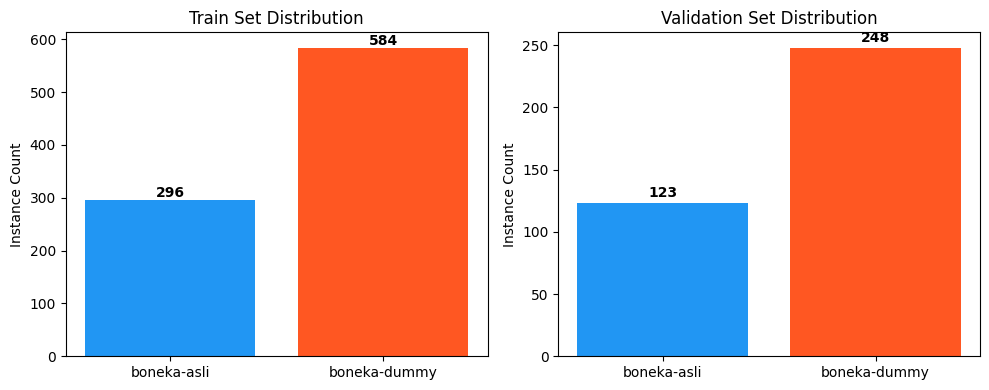


✅ Analisis selesai!


In [5]:
# ============================================================
# CELL 4: Analisis dataset
# Hasil analisis dari dataset ini:
#   - Train: 316 gambar | Valid: 136 gambar
#   - Class 0 (boneka-asli):  296 train,  123 valid
#   - Class 1 (boneka-dummy): 584 train,  248 valid  ← 2x lebih banyak!
#
# Catatan: class imbalance di atas dikompensasi langsung saat training
# lewat parameter cls_pw (lihat Cell 6 & 7), bukan dihitung manual di sini.
# ============================================================
import os
import glob
from collections import Counter
import matplotlib.pyplot as plt

CLASS_NAMES = ['boneka-asli', 'boneka-dummy']

def count_labels(label_dir):
    counter = Counter()
    for f in glob.glob(os.path.join(label_dir, '*.txt')):
        with open(f) as fp:
            for line in fp:
                cls = int(line.strip().split()[0])
                counter[cls] += 1
    return counter

train_counts = count_labels(os.path.join(DATASET_PATH, 'train/labels'))
valid_counts = count_labels(os.path.join(DATASET_PATH, 'valid/labels'))

print('='*50)
print('📊 DISTRIBUSI DATASET')
print('='*50)
for cls_id, name in enumerate(CLASS_NAMES):
    print(f'  {name:15s} → train: {train_counts[cls_id]:4d} | valid: {valid_counts[cls_id]:4d}')

ratio = max(train_counts.values()) / min(train_counts.values())
print(f'\n⚖️  Rasio imbalance: {ratio:.2f}x')
print(f'   → Dikompensasi via cls_pw=0.25 saat training (lihat Cell 6 & 7)')

# Plot distribusi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [(train_counts, 'Train'), (valid_counts, 'Validation')]):
    bars = ax.bar(CLASS_NAMES, [counts[0], counts[1]], color=['#2196F3', '#FF5722'])
    ax.set_title(f'{title} Set Distribution')
    ax.set_ylabel('Instance Count')
    for bar, val in zip(bars, [counts[0], counts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Analisis selesai!')

## ⏱️ CELL 4.5 — Cek Temporal Leakage Train/Valid Split

In [6]:
# ============================================================
# CELL 4.5: Cek apakah train/valid split bocor secara temporal
#
# Dataset ini berasal dari nama file berformat WIN_YYYYMMDD_HH_MM_SS,
# yang berarti foto diambil dari satu sesi rekaman/burst pada
# 12 Januari 2024 antara jam 17:42–18:25. Kalau frame-frame yang
# berdekatan waktu (mis. selisih beberapa detik) tersebar acak ke
# train DAN valid, model bisa "menghafal" background/pose dari frame
# tetangga di train — sehingga mAP validasi terlihat sangat tinggi
# tapi belum tentu menggambarkan performa di kondisi/venue baru.
#
# Cell ini HANYA mendiagnosis, tidak mengubah split apapun.
# ============================================================
import re
import os
import glob
from datetime import datetime

def parse_timestamp(filename):
    """Ekstrak timestamp dari nama file WIN_YYYYMMDD_HH_MM_SS_..."""
    m = re.search(r'WIN_(\d{8})_(\d{2})_(\d{2})_(\d{2})', filename)
    if not m:
        return None
    date_str, hh, mm, ss = m.groups()
    return datetime.strptime(f'{date_str}{hh}{mm}{ss}', '%Y%m%d%H%M%S')

train_files = glob.glob(os.path.join(DATASET_PATH, 'train/images/*.jpg'))
valid_files = glob.glob(os.path.join(DATASET_PATH, 'valid/images/*.jpg'))

train_ts = sorted([t for t in (parse_timestamp(f) for f in train_files) if t])
valid_ts = sorted([t for t in (parse_timestamp(f) for f in valid_files) if t])

if not train_ts or not valid_ts:
    print('⚠️  Tidak bisa mengekstrak timestamp dari nama file — lewati cek ini.')
else:
    print('='*60)
    print('⏱️  ANALISIS TEMPORAL SPLIT')
    print('='*60)
    print(f'Train: {len(train_ts)} file, rentang {train_ts[0].strftime("%H:%M:%S")} - {train_ts[-1].strftime("%H:%M:%S")}')
    print(f'Valid: {len(valid_ts)} file, rentang {valid_ts[0].strftime("%H:%M:%S")} - {valid_ts[-1].strftime("%H:%M:%S")}')

    # Untuk tiap file valid, cari jarak waktu terdekat ke file train manapun
    close_threshold_sec = 5  # frame dalam 5 detik dianggap "sangat mirip"
    close_pairs = 0
    for vt in valid_ts:
        min_diff = min(abs((vt - tt).total_seconds()) for tt in train_ts)
        if min_diff <= close_threshold_sec:
            close_pairs += 1

    pct_close = 100 * close_pairs / len(valid_ts)
    print(f'\n🔍 Gambar valid yang punya "tetangga" train dalam {close_threshold_sec} detik: '
          f'{close_pairs}/{len(valid_ts)} ({pct_close:.1f}%)')

    if pct_close > 30:
        print('\n⚠️  RISIKO TINGGI: sebagian besar valid set punya frame sangat')
        print('   berdekatan waktu di train set. Background, pose, dan motion')
        print('   blur kemungkinan besar nyaris identik antara train-valid.')
        print('   mAP 99%+ di sini KEMUNGKINAN tidak akan bertahan di kondisi')
        print('   lapangan baru (venue lomba, lighting beda, sudut kamera beda).')
        print('\n   💡 Saran: kalau memungkinkan, ambil data tambahan dari sesi')
        print('      rekaman BERBEDA (hari/lokasi/pencahayaan lain) khusus')
        print('      untuk dijadikan valid/test set, agar evaluasi lebih jujur.')
    else:
        print('\n✅ Risiko temporal leakage relatif rendah berdasarkan threshold ini.')


⏱️  ANALISIS TEMPORAL SPLIT
Train: 315 file, rentang 17:42:30 - 18:25:21
Valid: 135 file, rentang 17:42:15 - 18:25:27

🔍 Gambar valid yang punya "tetangga" train dalam 5 detik: 126/135 (93.3%)

⚠️  RISIKO TINGGI: sebagian besar valid set punya frame sangat
   berdekatan waktu di train set. Background, pose, dan motion
   blur kemungkinan besar nyaris identik antara train-valid.
   mAP 99%+ di sini KEMUNGKINAN tidak akan bertahan di kondisi
   lapangan baru (venue lomba, lighting beda, sudut kamera beda).

   💡 Saran: kalau memungkinkan, ambil data tambahan dari sesi
      rekaman BERBEDA (hari/lokasi/pencahayaan lain) khusus
      untuk dijadikan valid/test set, agar evaluasi lebih jujur.


## 🔀 CELL 4.6 — Re-split Train/Valid Berdasarkan Waktu (Mengatasi Temporal Leakage)

In [ ]:
# ============================================================
# CELL 4.6: Re-split dataset secara KRONOLOGIS, bukan acak
#
# Cell 4.5 menemukan 93.3% gambar valid punya "tetangga" dalam
# 5 detik di train set — split acak Roboflow tidak memperhitungkan
# bahwa data ini adalah burst foto dari satu sesi rekam berurutan.
#
# Solusi: gabungkan ulang train+valid jadi satu pool, urutkan
# berdasarkan timestamp asli, lalu potong di SALAH SATU JEDA WAKTU
# ALAMI (gap antar burst foto) yang paling dekat ke rasio 80/20.
# Ini memastikan valid set berasal dari rentang waktu yang TIDAK
# overlap dengan train set sama sekali — evaluasi jadi jujur.
#
# Dataset asli (DATASET_PATH) TIDAK diubah/ditimpa. Hasil split
# baru ditulis ke folder terpisah, lalu DATASET_PATH diarahkan
# ke situ supaya semua cell training setelah ini otomatis pakai
# split yang baru.
# ============================================================
import os
import re
import glob
import shutil
from datetime import datetime

def parse_ts(fname):
    m = re.search(r'WIN_(\d{8})_(\d{2})_(\d{2})_(\d{2})', fname)
    if not m:
        return None
    date_str, hh, mm, ss = m.groups()
    return datetime.strptime(f'{date_str}{hh}{mm}{ss}', '%Y%m%d%H%M%S')

# ── 1. Kumpulkan semua pasangan image+label dari train DAN valid ──
all_pairs = []  # (timestamp, image_path, label_path)
for split in ['train', 'valid']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    for img_path in glob.glob(os.path.join(img_dir, '*.jpg')):
        fname = os.path.basename(img_path)
        ts = parse_ts(fname)
        if ts is None:
            continue
        label_path = os.path.join(lbl_dir, fname.rsplit('.', 1)[0] + '.txt')
        all_pairs.append((ts, img_path, label_path))

all_pairs.sort(key=lambda x: x[0])
print(f'📦 Total gambar terkumpul (train+valid digabung): {len(all_pairs)}')
print(f'   Rentang waktu: {all_pairs[0][0].strftime("%H:%M:%S")} - {all_pairs[-1][0].strftime("%H:%M:%S")}')

# ── 2. Cari jeda waktu (gap) alami terdekat dengan target 80/20 ──
target_idx = int(len(all_pairs) * 0.8)
gaps = []
for i in range(1, len(all_pairs)):
    delta = (all_pairs[i][0] - all_pairs[i-1][0]).total_seconds()
    if delta > 30:  # gap > 30 detik dianggap jeda antar sesi/burst
        gaps.append((i, delta))

if gaps:
    # Pilih gap dengan index paling dekat ke target 80%
    split_idx, gap_size = min(gaps, key=lambda g: abs(g[0] - target_idx))
    print(f'\n🔍 Ditemukan {len(gaps)} jeda waktu > 30 detik antar foto.')
    print(f'   Split point dipilih di index {split_idx}/{len(all_pairs)} '
          f'({100*split_idx/len(all_pairs):.1f}%), pada jeda {gap_size:.0f} detik.')
else:
    split_idx = target_idx
    print(f'\n⚠️  Tidak ada jeda waktu alami ditemukan, pakai potongan 80% murni di index {split_idx}.')

train_pairs = all_pairs[:split_idx]
valid_pairs = all_pairs[split_idx:]

print(f'\n📊 Split baru:')
print(f'   Train: {len(train_pairs)} gambar  ({train_pairs[0][0].strftime("%H:%M:%S")} - {train_pairs[-1][0].strftime("%H:%M:%S")})')
print(f'   Valid: {len(valid_pairs)} gambar  ({valid_pairs[0][0].strftime("%H:%M:%S")} - {valid_pairs[-1][0].strftime("%H:%M:%S")})')

time_gap_sec = (valid_pairs[0][0] - train_pairs[-1][0]).total_seconds()
print(f'   Jarak waktu train-terakhir → valid-pertama: {time_gap_sec:.0f} detik (tidak overlap)')

# ── 3. Tulis ulang ke folder baru, JANGAN timpa dataset asli ──
RESPLIT_DIR = '/content/krsri_dataset_resplit'
if os.path.exists(RESPLIT_DIR):
    shutil.rmtree(RESPLIT_DIR)

for split_name, pairs in [('train', train_pairs), ('valid', valid_pairs)]:
    img_out = os.path.join(RESPLIT_DIR, split_name, 'images')
    lbl_out = os.path.join(RESPLIT_DIR, split_name, 'labels')
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    for ts, img_path, label_path in pairs:
        shutil.copy2(img_path, img_out)
        if os.path.exists(label_path):
            shutil.copy2(label_path, lbl_out)

# ── 4. Verifikasi class balance tidak timpang ekstrem setelah re-split ──
from collections import Counter

def count_labels(label_dir):
    counter = Counter()
    for f in glob.glob(os.path.join(label_dir, '*.txt')):
        with open(f) as fp:
            for line in fp:
                cls = int(line.strip().split()[0])
                counter[cls] += 1
    return counter

new_train_counts = count_labels(os.path.join(RESPLIT_DIR, 'train', 'labels'))
new_valid_counts = count_labels(os.path.join(RESPLIT_DIR, 'valid', 'labels'))

print(f'\n📊 Distribusi kelas setelah re-split:')
for cls_id, name in enumerate(CLASS_NAMES):
    print(f'  {name:15s} → train: {new_train_counts[cls_id]:4d} | valid: {new_valid_counts[cls_id]:4d}')

if new_valid_counts[0] == 0 or new_valid_counts[1] == 0:
    print('\n🚨 PERINGATAN: salah satu kelas TIDAK ADA di valid set baru!')
    print('   Split kronologis ini tidak bisa dipakai apa adanya — kemungkinan')
    print('   urutan pengambilan foto dikelompokkan per kelas (semua boneka-asli')
    print('   difoto dulu, baru semua boneka-dummy, atau sebaliknya).')
    print('   DATASET_PATH TIDAK diubah — cell training berikutnya tetap pakai')
    print('   split original. Tinjau manual sebelum lanjut.')
else:
    # ── 5. Arahkan DATASET_PATH ke split baru ──
    DATASET_PATH = RESPLIT_DIR
    print(f'\n✅ DATASET_PATH diarahkan ke split baru: {DATASET_PATH}')
    print('   Cell training (6, 7, dst) sekarang akan otomatis pakai split ini.')


## 🖼️ CELL 5 — Custom Augmented Dataset (Albumentations)

In [7]:
# ============================================================
# CELL 5: Buat data.yaml yang dioptimalkan
# Augmentasi di-handle oleh Ultralytics params di training
# ============================================================
import yaml

data_config = {
    'path': DATASET_PATH,
    'train': 'train/images',
    'val': 'valid/images',
    'nc': 2,
    'names': CLASS_NAMES
}

DATA_YAML = '/content/krsri_optimized.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f'✅ data.yaml saved: {DATA_YAML}')
print(yaml.dump(data_config))

✅ data.yaml saved: /content/krsri_optimized.yaml
names:
- boneka-asli
- boneka-dummy
nc: 2
path: /content/krsri_dataset
train: train/images
val: valid/images



## 🔥 CELL 6 — Phase 1: Frozen Backbone Training (Warm-up)

In [8]:
# ============================================================
# CELL 6: PHASE 1 — Freeze backbone, train head saja
# Tujuan: biarkan head beradaptasi ke dataset kita dulu
# sebelum full fine-tune. Ini mencegah catastrophic forgetting.
# ============================================================
from ultralytics import YOLO

print('🚀 Phase 1: Training dengan frozen backbone...')
print('   Model: YOLOv8s (Small) — balance akurasi vs kecepatan')
print('   Mode: Freeze 10 layers backbone, train detection head')
print('='*60)

# Load YOLOv8s pretrained pada COCO
model = YOLO('yolov8s.pt')

results_phase1 = model.train(
    # ── Dataset ──────────────────────────────────────────────
    data=DATA_YAML,

    # ── Training Config ──────────────────────────────────────
    epochs=30,              # Phase 1: 30 epoch, head adaptation
    imgsz=640,              # Resolusi training
    batch=16,               # Sesuai VRAM T4 Colab
    workers=4,

    # ── Freeze backbone untuk phase 1 ────────────────────────
    freeze=10,              # Freeze 10 layer pertama (backbone)

    # ── Learning Rate ────────────────────────────────────────
    optimizer='AdamW',      # AdamW lebih stabil untuk fine-tune
    lr0=1e-3,               # LR awal phase 1 (head saja)
    lrf=0.01,               # Final LR = lr0 * lrf
    momentum=0.937,
    weight_decay=5e-4,
    warmup_epochs=3.0,      # 3 epoch warmup
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    # ── Loss Weights ─────────────────────────────────────────
    box=7.5,                # Box loss weight
    cls=0.5,                # Classification loss (dinaikkan utk 2 kelas)
    dfl=1.5,                # Distribution focal loss
    cls_pw=0.25,            # Class weighting inverse-frequency (imbalance 1:2,
                            # boneka-dummy 2x lebih banyak dari boneka-asli).
                            # 0.25 = moderate, sesuai rekomendasi resmi Ultralytics
                            # untuk imbalance moderat (naikkan ke 1.0 jika kelas
                            # minoritas masih underperform).

    # ── Augmentasi Phase 1 (moderate) ────────────────────────
    hsv_h=0.015,            # Hue shift (perubahan warna pencahayaan)
    hsv_s=0.7,              # Saturation (variasi kondisi lighting)
    hsv_v=0.4,              # Value/brightness
    degrees=15,             # Rotasi ±15°
    translate=0.1,          # Translasi posisi
    scale=0.5,              # Scale ±50%
    shear=5.0,              # Shear transform
    perspective=0.0005,     # Perspective transform (simulasi sudut kamera)
    flipud=0.0,             # Jangan flip vertikal (boneka punya orientasi)
    fliplr=0.5,             # Flip horizontal OK
    mosaic=1.0,             # Mosaic augmentation (sangat membantu dataset kecil)
    mixup=0.1,              # MixUp (moderate di phase 1)
    # copy_paste dimatikan (0, sebelumnya 0.1) — alasan sama seperti
    # di Phase 2: dataset ini tidak punya data segment/polygon,
    # jadi augmentasi ini kemungkinan besar tidak benar-benar berefek.
    copy_paste=0.0,
    auto_augment='randaugment',  # Auto augmentation policy
    erasing=0.4,            # Random erasing untuk robustness

    # ── Regularization ───────────────────────────────────────
    dropout=0.0,
    # Catatan: 'label_smoothing' dihapus — versi ultralytics terbaru
    # menandainya deprecated tanpa pengganti resmi yang dikonfirmasi,
    # dan log training sebelumnya sudah menunjukkan parameter ini
    # diabaikan ("WARNING ⚠️ 'label_smoothing' is deprecated").

    # ── Cosine LR Scheduler ──────────────────────────────────
    cos_lr=True,            # Cosine annealing LR (lebih smooth)

    # ── Early Stopping & Checkpoint ──────────────────────────
    patience=15,            # Early stop jika tidak improve 15 epoch
    save=True,
    save_period=5,          # Simpan checkpoint tiap 5 epoch

    # ── Output ───────────────────────────────────────────────
    project='/content/runs',
    name='phase1_frozen',
    exist_ok=True,

    # ── Device & Performance ─────────────────────────────────
    device=0,               # GPU
    amp=True,               # Mixed precision training (lebih cepat)
    cache=True,             # Cache images di RAM (penting utk dataset kecil)
    verbose=True,

    # ── Validation ───────────────────────────────────────────
    val=True,
    plots=True,
)

print('\n✅ Phase 1 selesai!')
print(f'   Best mAP50: {results_phase1.results_dict.get("metrics/mAP50(B)", 0):.4f}')

🚀 Phase 1: Training dengan frozen backbone...
   Model: YOLOv8s (Small) — balance akurasi vs kecepatan
   Mode: Freeze 10 layers backbone, train detection head
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.25, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/krsri_optimized.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8

## 🏋️ CELL 7 — Phase 2: Full Fine-Tuning

In [9]:
# ============================================================
# CELL 7: PHASE 2 — Full fine-tune semua layer
# Load best weight dari phase 1, unfreeze semua layer,
# training dengan LR rendah agar tidak destroy pretrained features
# ============================================================
from ultralytics import YOLO
import os

PHASE1_BEST = '/content/runs/phase1_frozen/weights/best.pt'
print(f'🚀 Phase 2: Full fine-tune dari {PHASE1_BEST}')
print('   Mode: Semua layer di-train, LR lebih rendah')
print('='*60)

model = YOLO(PHASE1_BEST)

results_phase2 = model.train(
    # ── Dataset ──────────────────────────────────────────────
    data=DATA_YAML,

    # ── Training Config ──────────────────────────────────────
    epochs=150,             # Phase 2: epoch lebih banyak
    imgsz=640,
    batch=16,
    workers=4,

    # ── NO freeze di phase 2 ─────────────────────────────────
    freeze=None,            # Semua layer dilatih

    # ── Learning Rate (lebih kecil untuk full fine-tune) ─────
    optimizer='AdamW',
    lr0=1e-4,               # LR awal lebih rendah (jangan rusak phase 1)
    lrf=0.001,              # Final LR sangat kecil
    momentum=0.937,
    weight_decay=5e-4,
    warmup_epochs=2.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.01,

    # ── Loss Weights ─────────────────────────────────────────
    box=7.5,
    cls=0.5,
    dfl=1.5,
    cls_pw=0.25,            # Konsisten dengan Phase 1 — class weighting
                            # inverse-frequency untuk imbalance 1:2.

    # ── Augmentasi Phase 2 (lebih agresif) ───────────────────
    # HSV dinaikkan dari versi sebelumnya (0.02/0.8/0.5) untuk coba
    # kurangi ketergantungan model pada warna semata — video uji
    # menunjukkan model sempat salah deteksi warna kuning-oranye
    # robot sebagai boneka-asli. Tetap moderat (jauh dari batas 1.0)
    # supaya warna boneka-asli vs boneka-dummy tidak jadi terlalu
    # acak untuk dibedakan satu sama lain.
    hsv_h=0.03,              # Hue shift (naik dari 0.02)
    hsv_s=0.9,               # Saturation (naik dari 0.8)
    hsv_v=0.6,               # Brightness (naik dari 0.5)
    degrees=20,              # Rotasi ±20°
    translate=0.15,
    scale=0.6,
    shear=8.0,
    perspective=0.001,
    flipud=0.0,              # Tetap jangan flip vertikal
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.2,               # MixUp lebih tinggi di phase 2
    # copy_paste dimatikan (0, sebelumnya 0.2) — dataset Roboflow
    # ini format deteksi standar (bounding box saja, tanpa polygon
    # segment), dan copy_paste di Ultralytics bergantung pada data
    # segment untuk benar-benar memotong-tempel objek. Tanpa segment,
    # augmentasi ini kemungkinan besar tidak benar-benar berefek
    # (dikonfirmasi laporan serupa di issue resmi ultralytics #18073),
    # jadi dimatikan saja daripada membuang compute untuk efek nol.
    copy_paste=0.0,
    auto_augment='randaugment',
    erasing=0.5,

    # ── Regularization ───────────────────────────────────────
    dropout=0.0,
    # 'label_smoothing' dihapus (lihat catatan di Phase 1).

    # ── Cosine LR ────────────────────────────────────────────
    cos_lr=True,

    # ── Early Stopping ───────────────────────────────────────
    patience=30,            # Phase 2 butuh lebih banyak patience
    save=True,
    save_period=10,

    # ── Output ───────────────────────────────────────────────
    project='/content/runs',
    name='phase2_fulltune',
    exist_ok=True,

    # ── Device ───────────────────────────────────────────────
    device=0,
    amp=True,
    cache=True,
    verbose=True,
    val=True,
    plots=True,
)

BEST_WEIGHTS = '/content/runs/phase2_fulltune/weights/best.pt'
print('\n✅ Phase 2 selesai!')
print(f'   Best mAP50:    {results_phase2.results_dict.get("metrics/mAP50(B)", 0):.4f}')
print(f'   Best mAP50-95: {results_phase2.results_dict.get("metrics/mAP50-95(B)", 0):.4f}')
print(f'   Best weights: {BEST_WEIGHTS}')

🚀 Phase 2: Full fine-tune dari /content/runs/phase1_frozen/weights/best.pt
   Mode: Semua layer di-train, LR lebih rendah
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.25, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/krsri_optimized.yaml, degrees=20, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.5, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/runs/phase1_frozen/weights/best

## 📊 CELL 8 — Evaluasi Mendalam dengan TTA

In [10]:
# ============================================================
# CELL 8: Evaluasi lengkap dengan Test-Time Augmentation (TTA)
# TTA: jalankan prediksi pada beberapa variasi gambar,
# lalu ensemble hasilnya → confidence lebih tinggi & stabil
# ============================================================
from ultralytics import YOLO
import json

BEST_WEIGHTS = '/content/runs/phase2_fulltune/weights/best.pt'
model = YOLO(BEST_WEIGHTS)

print('📊 Evaluasi tanpa TTA...')
metrics_no_tta = model.val(
    data=DATA_YAML,
    imgsz=640,
    batch=16,
    conf=0.001,     # Conf rendah untuk hitung mAP
    iou=0.6,
    device=0,
    plots=True,
    save_json=True,
)

print('\n📊 Evaluasi DENGAN TTA...')
metrics_tta = model.val(
    data=DATA_YAML,
    imgsz=640,
    batch=16,
    conf=0.001,
    iou=0.6,
    augment=True,   # ← TTA aktif
    device=0,
    plots=False,
)

print('\n' + '='*60)
print('📈 PERBANDINGAN PERFORMA')
print('='*60)
print(f'{"Metric":<25} {"No TTA":>10} {"With TTA":>10}')
print('-'*50)

metrics_map = [
    ('mAP50', 'metrics/mAP50(B)'),
    ('mAP50-95', 'metrics/mAP50-95(B)'),
    ('Precision', 'metrics/precision(B)'),
    ('Recall', 'metrics/recall(B)'),
]
for label, key in metrics_map:
    v1 = metrics_no_tta.results_dict.get(key, 0)
    v2 = metrics_tta.results_dict.get(key, 0)
    delta = v2 - v1
    sign = '+' if delta > 0 else ''
    print(f'{label:<25} {v1:>10.4f} {v2:>10.4f}  ({sign}{delta:.4f})')

# Per-class metrics
print('\n📊 Per-Class AP50:')
if hasattr(metrics_no_tta, 'ap_class_index'):
    for i, cls_id in enumerate(metrics_no_tta.ap_class_index):
        ap = metrics_no_tta.box.ap50[i]
        print(f'  {CLASS_NAMES[cls_id]:15s}: AP50 = {ap:.4f}')

📊 Evaluasi tanpa TTA...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1577.2±370.8 MB/s, size: 36.2 KB)
val: Scanning /content/krsri_dataset/valid/labels.cache... 135 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 135/135 37.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.4it/s 3.7s
                   all        135        371      0.991          1      0.995      0.906
           boneka-asli        123        123          1          1      0.995      0.885
          boneka-dummy        132        248      0.981          1      0.995      0.926
Speed: 3.1ms preprocess, 10.0ms inference, 0.0ms loss, 5.2ms postprocess per image
Saving /content/runs/detect/val/predictions.json...
Results saved to /content/runs/detect/val

📊 Evaluasi DENGAN T

## 🎯 CELL 8.5 — Diagnosis Gap mAP50 vs mAP50-95 (Confusion Matrix & IoU)

⚠️  Confusion matrix tidak ditemukan di /content/runs/detect/val-2
📊 DISTRIBUSI IoU PER KELAS (ground truth vs prediksi terbaik)

boneka-asli:
  Mean IoU      : 0.915
  Median IoU    : 0.924
  % IoU < 0.75  : 1.6%  (ini yang bikin mAP50-95 turun)
  % IoU < 0.50  : 0.0%  (ini yang bikin mAP50 turun)

boneka-dummy:
  Mean IoU      : 0.938
  Median IoU    : 0.943
  % IoU < 0.75  : 0.0%  (ini yang bikin mAP50-95 turun)
  % IoU < 0.50  : 0.0%  (ini yang bikin mAP50 turun)


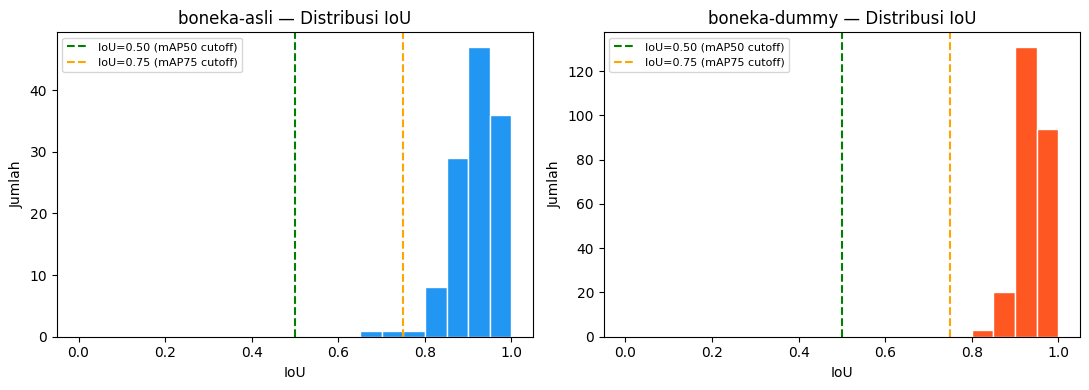


✅ Diagnosis selesai! Lihat histogram: semakin banyak batang di kiri 0.75,
   semakin besar kontribusinya ke gap mAP50 vs mAP50-95.


In [11]:
# ============================================================
# CELL 8.5: Diagnosis kenapa mAP50-95 lebih rendah dari mAP50
#
# mAP50 menilai "apakah box prediksi overlap >=50% dengan ground
# truth" — syarat longgar. mAP50-95 rata-rata dari threshold IoU
# 50% sampai 95% — syarat jauh lebih ketat soal presisi lokasi box.
# Gap besar antara keduanya berarti: model hampir selalu BENAR
# mendeteksi keberadaan boneka, tapi kotaknya tidak selalu pas
# menutupi boneka secara presisi.
#
# Cell ini menampilkan confusion matrix (sudah otomatis dibuat saat
# model.val(plots=True) di Cell 8) dan menghitung distribusi IoU
# aktual pada validation set untuk melihat di kelas mana presisi
# box paling sering meleset.
# ============================================================
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# ── 1. Tampilkan confusion matrix yang sudah digenerate Cell 8 ──
# Pakai save_dir dari objek hasil model.val() di Cell 8 secara langsung
# (metrics_no_tta), bukan menebak nama folder lewat glob+mtime — Colab
# bisa membuat val, val-2, val-3, dst kalau dijalankan berkali-kali,
# dan urutan mtime tidak selalu cocok urutan eksekusi sebenarnya.
try:
    val_save_dir = str(metrics_no_tta.save_dir)
except NameError:
    val_save_dir = None
    print('⚠️  Variabel metrics_no_tta tidak ditemukan — jalankan Cell 8 terlebih dahulu.')

if val_save_dir:
    cm_path = os.path.join(val_save_dir, 'confusion_matrix_normalized.png')
    if os.path.exists(cm_path):
        img = Image.open(cm_path)
        plt.figure(figsize=(7, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Confusion Matrix (Normalized)', fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'⚠️  Confusion matrix tidak ditemukan di {val_save_dir}')
        print('   (pastikan Cell 8 dijalankan dengan plots=True)')

# ── 2. Hitung distribusi IoU prediksi vs ground truth ───────────
def compute_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def load_gt_boxes(label_path, img_w, img_h):
    """Load YOLO-format label dan convert ke pixel xyxy."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            x1 = (xc - w/2) * img_w
            y1 = (yc - h/2) * img_h
            x2 = (xc + w/2) * img_w
            y2 = (yc + h/2) * img_h
            boxes.append((cls_id, [x1, y1, x2, y2]))
    return boxes

BEST_WEIGHTS = '/content/runs/phase2_fulltune/weights/best.pt'
model = YOLO(BEST_WEIGHTS)

val_images = sorted(glob.glob(os.path.join(DATASET_PATH, 'valid/images/*.jpg')))
iou_by_class = {0: [], 1: []}

for img_path in val_images:
    label_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    img = Image.open(img_path)
    img_w, img_h = img.size
    gt_boxes = load_gt_boxes(label_path, img_w, img_h)
    if not gt_boxes:
        continue

    result = model.predict(img_path, imgsz=640, conf=0.25, iou=0.45, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        continue

    pred_boxes = result.boxes.xyxy.cpu().numpy()
    pred_classes = result.boxes.cls.cpu().numpy().astype(int)

    # Match tiap GT ke prediksi terbaik dengan kelas sama
    for gt_cls, gt_box in gt_boxes:
        best_iou = 0
        for pbox, pcls in zip(pred_boxes, pred_classes):
            if pcls == gt_cls:
                iou = compute_iou(gt_box, pbox)
                best_iou = max(best_iou, iou)
        if gt_cls in iou_by_class:
            iou_by_class[gt_cls].append(best_iou)

print('='*60)
print('📊 DISTRIBUSI IoU PER KELAS (ground truth vs prediksi terbaik)')
print('='*60)
for cls_id, name in enumerate(CLASS_NAMES):
    ious = iou_by_class[cls_id]
    if ious:
        ious = np.array(ious)
        print(f'\n{name}:')
        print(f'  Mean IoU      : {ious.mean():.3f}')
        print(f'  Median IoU    : {np.median(ious):.3f}')
        print(f'  % IoU < 0.75  : {100*(ious < 0.75).mean():.1f}%  (ini yang bikin mAP50-95 turun)')
        print(f'  % IoU < 0.50  : {100*(ious < 0.50).mean():.1f}%  (ini yang bikin mAP50 turun)')

# Plot histogram IoU per kelas
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cls_id, name in zip(axes, [0, 1], CLASS_NAMES):
    ious = iou_by_class[cls_id]
    if ious:
        ax.hist(ious, bins=20, range=(0, 1), color='#2196F3' if cls_id==0 else '#FF5722', edgecolor='white')
        ax.axvline(0.5, color='green', linestyle='--', label='IoU=0.50 (mAP50 cutoff)')
        ax.axvline(0.75, color='orange', linestyle='--', label='IoU=0.75 (mAP75 cutoff)')
        ax.set_title(f'{name} — Distribusi IoU')
        ax.set_xlabel('IoU')
        ax.set_ylabel('Jumlah')
        ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/iou_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Diagnosis selesai! Lihat histogram: semakin banyak batang di kiri 0.75,')
print('   semakin besar kontribusinya ke gap mAP50 vs mAP50-95.')

## 📉 CELL 9 — Visualisasi Training Curves

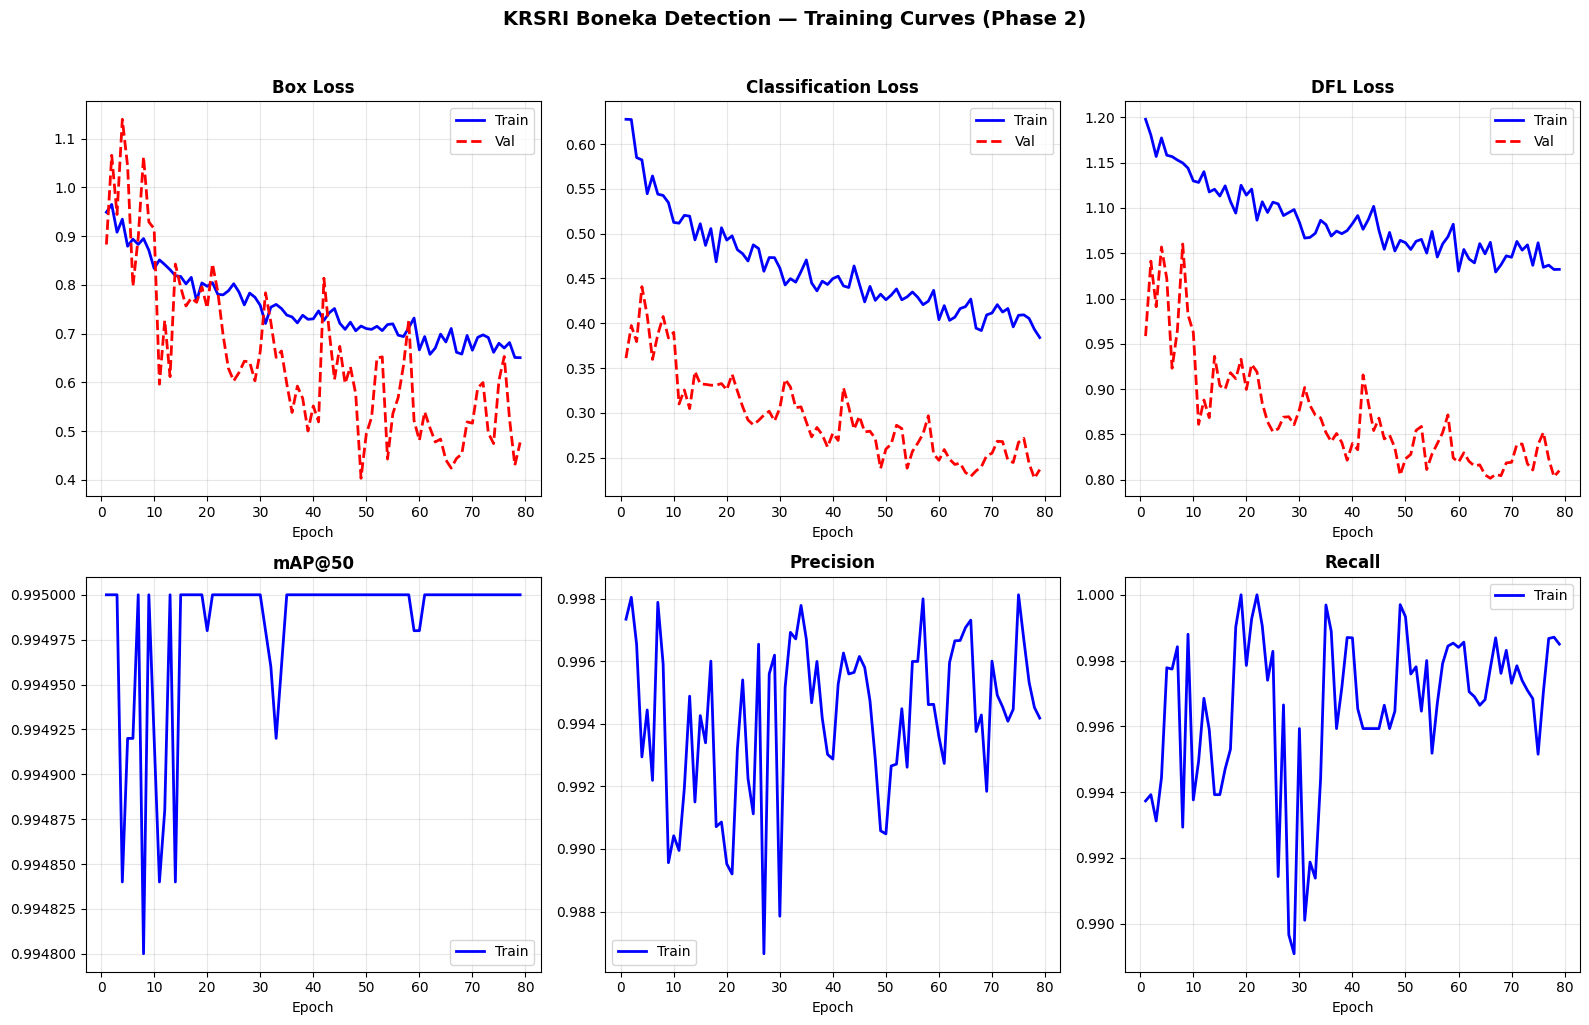

✅ Curve saved!


In [12]:
# ============================================================
# CELL 9: Plot training curves untuk analisis
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load results CSV dari phase 2
csv_path = '/content/runs/phase2_fulltune/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

plots = [
    ('train/box_loss', 'val/box_loss', 'Box Loss'),
    ('train/cls_loss', 'val/cls_loss', 'Classification Loss'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss'),
    ('metrics/mAP50(B)', None, 'mAP@50'),
    ('metrics/precision(B)', None, 'Precision'),
    ('metrics/recall(B)', None, 'Recall'),
]

for idx, (train_col, val_col, title) in enumerate(plots):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    if train_col in df.columns:
        ax.plot(df['epoch'], df[train_col], 'b-', label='Train', linewidth=2)
    if val_col and val_col in df.columns:
        ax.plot(df['epoch'], df[val_col], 'r--', label='Val', linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('KRSRI Boneka Detection — Training Curves (Phase 2)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curve saved!')

## 🚀 CELL 10 — Export Model untuk Raspberry Pi

In [13]:
# ============================================================
# CELL 10: Export model ke berbagai format
# ============================================================
from ultralytics import YOLO
import shutil
import os

BEST_WEIGHTS = '/content/runs/phase2_fulltune/weights/best.pt'
model = YOLO(BEST_WEIGHTS)

print('🔄 Mengexport model...')
print('='*50)

# ── 1. Export NCNN (TERBAIK untuk Raspi) ──────────────────
print('\n[1/3] Exporting ke NCNN...')
model.export(
    format='ncnn',
    imgsz=640,
    quantize=32,        # FP32 — NCNN di ARM CPU tidak diuntungkan FP16
)
print('    ✅ NCNN exported!')

# ── 2. Export ONNX (backup / testing) ─────────────────────
print('\n[2/3] Exporting ke ONNX...')
model.export(
    format='onnx',
    imgsz=640,
    quantize=32,
    simplify=True,
    opset=12,
    dynamic=False,
)
print('    ✅ ONNX exported!')

# ── 3. Simpan semua ke Google Drive ───────────────────────
print(f'\n[3/3] Menyimpan ke Google Drive: {SAVE_DIR}')

files_to_save = [
    (BEST_WEIGHTS, f'{SAVE_DIR}/best_yolov8s.pt'),
    (BEST_WEIGHTS.replace('.pt', '.onnx'), f'{SAVE_DIR}/best_yolov8s.onnx'),
    (DATA_YAML, f'{SAVE_DIR}/data.yaml'),
    ('/content/training_curves.png', f'{SAVE_DIR}/training_curves.png'),
    ('/content/class_distribution.png', f'{SAVE_DIR}/class_distribution.png'),
    ('/content/iou_distribution.png', f'{SAVE_DIR}/iou_distribution.png'),
]

ncnn_dir = BEST_WEIGHTS.replace('.pt', '_ncnn_model')
if os.path.isdir(ncnn_dir):
    shutil.copytree(ncnn_dir, f'{SAVE_DIR}/best_ncnn_model', dirs_exist_ok=True)
    print(f'    ✅ NCNN model folder saved')

for src, dst in files_to_save:
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size = os.path.getsize(dst) / 1024 / 1024
        print(f'    ✅ {os.path.basename(dst):30s} ({size:.1f} MB)')
    else:
        print(f'    ⚠️  Not found: {src}')

print('\n🎉 Export selesai!')

🔄 Mengexport model...

[1/3] Exporting ke NCNN...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/runs/phase2_fulltune/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (21.5 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 231ms
Prepared 1 package in 252ms
Installed 1 package in 3ms
 + ncnn==1.0.20260526

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] 

## 🧪 CELL 11 — Konfirmasi Model: Inference Test di Colab

🔍 Testing pada 6 gambar validasi...


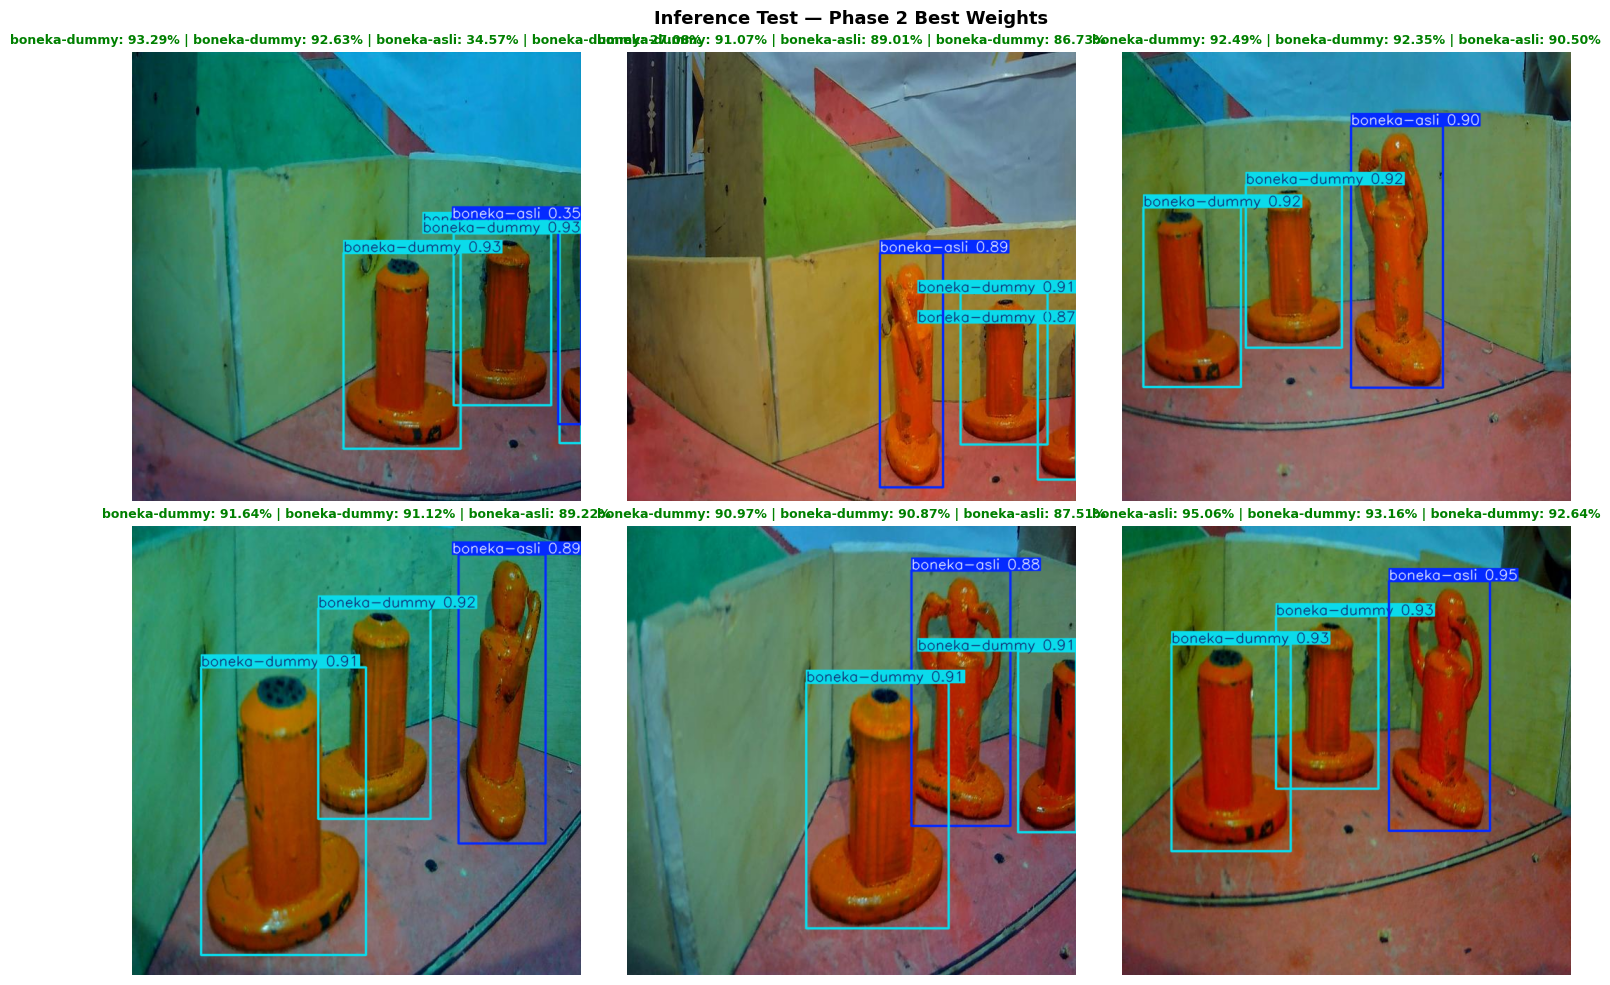


📊 Confidence Summary:
   Total deteksi : 19
   Avg confidence: 84.84%
   Min confidence: 27.08%
   Max confidence: 95.06%


In [14]:
# ============================================================
# CELL 11: Test inferensi di Colab sebelum deploy ke Raspi
# Tampilkan confidence score per deteksi
# ============================================================
from ultralytics import YOLO
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

BEST_WEIGHTS = '/content/runs/phase2_fulltune/weights/best.pt'
model = YOLO(BEST_WEIGHTS)

# Ambil 6 sample dari validation set
val_images = glob.glob(os.path.join(DATASET_PATH, 'valid/images/*.jpg'))[:6]

print(f'🔍 Testing pada {len(val_images)} gambar validasi...')
print('='*60)

# Run inference dengan TTA
results = model.predict(
    source=val_images,
    imgsz=640,
    conf=0.25,          # Confidence threshold
    iou=0.45,           # NMS IoU threshold
    augment=True,       # TTA untuk confidence lebih tinggi
    verbose=False,
    save=False,
)

# Plot hasil
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

all_confidences = []
for idx, (result, ax) in enumerate(zip(results, axes)):
    # Plot image dengan bounding box
    img_annotated = result.plot()
    ax.imshow(img_annotated[:, :, ::-1])  # BGR → RGB
    ax.axis('off')

    # Extract detections
    if result.boxes is not None and len(result.boxes) > 0:
        confs = result.boxes.conf.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)
        all_confidences.extend(confs.tolist())

        det_info = []
        for cls_id, conf in zip(classes, confs):
            det_info.append(f'{CLASS_NAMES[cls_id]}: {conf:.2%}')
        title = ' | '.join(det_info)
        ax.set_title(title, fontsize=9, color='green', fontweight='bold')
    else:
        ax.set_title('No detection', fontsize=9, color='red')

plt.suptitle('Inference Test — Phase 2 Best Weights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/inference_test.png', dpi=150, bbox_inches='tight')
plt.show()

if all_confidences:
    avg_conf = np.mean(all_confidences)
    print(f'\n📊 Confidence Summary:')
    print(f'   Total deteksi : {len(all_confidences)}')
    print(f'   Avg confidence: {avg_conf:.2%}')
    print(f'   Min confidence: {min(all_confidences):.2%}')
    print(f'   Max confidence: {max(all_confidences):.2%}')

## 📱 CELL 12 — Script Inferensi untuk Raspberry Pi 4

In [15]:
# ============================================================
# CELL 12: Generate script inferensi Raspberry Pi
# Script ini di-save dan di-copy ke Raspi bersama model NCNN
# ============================================================

raspi_script = '''
#!/usr/bin/env python3
"""
KRSRI Boneka Detection — Raspberry Pi 4 Inference Script
=========================================================
Model  : YOLOv8s NCNN (optimized for ARM)
Target : Raspberry Pi 4 + Pi Camera v2 / USB Camera

Dependencies:
    pip install ultralytics opencv-python

Usage:
    # Kamera realtime:
    python3 raspi_detect.py --source 0

    # Pi Camera:
    python3 raspi_detect.py --source picam

    # Image file:
    python3 raspi_detect.py --source image.jpg

    # Video file:
    python3 raspi_detect.py --source video.mp4
"""

import argparse
import time
import sys
import os
from pathlib import Path

import cv2
import numpy as np
from ultralytics import YOLO


# ═══════════════════════════════════════════════════════════
# KONFIGURASI — sesuaikan dengan kondisi lapangan
# ═══════════════════════════════════════════════════════════
MODEL_PATH   = "best_ncnn_model"   # Folder model NCNN
CLASS_NAMES  = ["boneka-asli", "boneka-dummy"]
CLASS_COLORS = {
    0: (0, 255, 0),    # boneka-asli  → Hijau
    1: (0, 0, 255),    # boneka-dummy → Merah
}

# Threshold inferensi
CONF_THRESHOLD = 0.50   # Naikkan jika terlalu banyak false positive
IOU_THRESHOLD  = 0.45   # NMS IoU
IMGSZ          = 416    # Kecilkan resolusi untuk Raspi (320/416/640)
                        # 320 → paling cepat, 640 → paling akurat

# ═══════════════════════════════════════════════════════════

def parse_args():
    parser = argparse.ArgumentParser(description="KRSRI Boneka Detector")
    parser.add_argument("--source", default="0",
                        help="Input: 0=webcam, picam, image.jpg, video.mp4")
    parser.add_argument("--conf",   type=float, default=CONF_THRESHOLD)
    parser.add_argument("--imgsz",  type=int,   default=IMGSZ)
    parser.add_argument("--save",   action="store_true", help="Simpan output")
    parser.add_argument("--headless", action="store_true",
                        help="Mode tanpa display (untuk robot tanpa monitor)")
    return parser.parse_args()


def load_model(model_path: str, imgsz: int) -> YOLO:
    """Load NCNN model dengan validasi."""
    if not os.path.exists(model_path):
        print(f"[ERROR] Model tidak ditemukan: {model_path}")
        print("  Pastikan folder NCNN ada di direktori yang sama.")
        sys.exit(1)

    print(f"[INFO] Loading model: {model_path}")
    print(f"[INFO] Image size  : {imgsz}x{imgsz}")
    model = YOLO(model_path, task="detect")

    # Warmup: run sekali untuk inisialisasi
    print("[INFO] Warming up model...")
    dummy = np.zeros((imgsz, imgsz, 3), dtype=np.uint8)
    model.predict(dummy, imgsz=imgsz, verbose=False)
    print("[INFO] Model ready!\n")
    return model


def open_capture(source: str) -> cv2.VideoCapture:
    """Buka input video/camera."""
    if source == "picam":
        # Pi Camera via libcamera (Raspi OS Bullseye+)
        try:
            cap = cv2.VideoCapture("libcamerasrc ! videoconvert ! "
                                   "video/x-raw,format=BGR ! appsink",
                                   cv2.CAP_GSTREAMER)
            if not cap.isOpened():
                raise RuntimeError("libcamera tidak tersedia")
        except Exception:
            # Fallback ke indeks 0
            print("[WARN] libcamera tidak tersedia, pakai /dev/video0")
            cap = cv2.VideoCapture(0)
    elif source.isdigit():
        cap = cv2.VideoCapture(int(source))
        # Resolusi optimal untuk USB cam di Raspi
        cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        cap.set(cv2.CAP_PROP_FPS, 30)
    else:
        # Image atau video file
        cap = cv2.VideoCapture(source)

    if not cap.isOpened():
        print(f"[ERROR] Tidak bisa membuka source: {source}")
        sys.exit(1)

    return cap


def draw_detections(frame: np.ndarray, result, conf_threshold: float) -> tuple:
    """
    Gambar bounding box dan label pada frame.
    Return: (annotated_frame, detections_list)
    """
    detections = []

    if result.boxes is None or len(result.boxes) == 0:
        return frame, detections

    boxes  = result.boxes.xyxy.cpu().numpy()
    confs  = result.boxes.conf.cpu().numpy()
    clsids = result.boxes.cls.cpu().numpy().astype(int)

    for box, conf, cls_id in zip(boxes, confs, clsids):
        if conf < conf_threshold:
            continue

        x1, y1, x2, y2 = box.astype(int)
        color      = CLASS_COLORS.get(cls_id, (255, 255, 255))
        label      = CLASS_NAMES[cls_id]
        label_text = f"{label}: {conf:.0%}"

        # Bounding box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Label background
        (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(frame, (x1, y1 - th - 10), (x1 + tw + 6, y1), color, -1)
        cv2.putText(frame, label_text, (x1 + 3, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        detections.append({"class": label, "class_id": cls_id, "confidence": float(conf),
                           "bbox": [x1, y1, x2, y2]})

    return frame, detections


def run_inference(model: YOLO, args):
    """Loop inferensi utama."""
    source = args.source
    is_image = source.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))

    if is_image:
        # ── Inferensi single image ────────────────────────────
        frame = cv2.imread(source)
        if frame is None:
            print(f"[ERROR] Gambar tidak bisa dibaca: {source}")
            return

        result = model.predict(
            frame, imgsz=args.imgsz, conf=args.conf,
            iou=IOU_THRESHOLD, verbose=False
        )[0]

        frame, detections = draw_detections(frame, result, args.conf)
        print(f"\n[RESULT] Deteksi ({len(detections)} objek):")
        for d in detections:
            print(f"  → {d['class']:15s} conf={d['confidence']:.2%}  bbox={d['bbox']}")

        if args.save:
            out_path = "output_" + os.path.basename(source)
            cv2.imwrite(out_path, frame)
            print(f"[INFO] Hasil disimpan: {out_path}")

        if not args.headless:
            cv2.imshow("KRSRI Detection", frame)
            cv2.waitKey(0)
            cv2.destroyAllWindows()
        return

    # ── Inferensi video / kamera ──────────────────────────────
    cap = open_capture(source)

    # Setup video writer jika save
    writer = None
    if args.save:
        fps = cap.get(cv2.CAP_PROP_FPS) or 20
        w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        writer = cv2.VideoWriter("output_detection.mp4",
                                  cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    # FPS tracking
    fps_counter = 0
    fps_display = 0
    t_start = time.time()

    print("[INFO] Mulai inferensi. Tekan 'q' untuk berhenti.")
    print(f"[INFO] Confidence threshold: {args.conf:.0%}")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # ── Inferensi ────────────────────────────────────────
        t0 = time.perf_counter()
        result = model.predict(
            frame,
            imgsz=args.imgsz,
            conf=args.conf,
            iou=IOU_THRESHOLD,
            verbose=False,
            stream=False,
        )[0]
        t1 = time.perf_counter()
        infer_ms = (t1 - t0) * 1000

        # ── Draw ─────────────────────────────────────────────
        frame, detections = draw_detections(frame, result, args.conf)

        # ── FPS overlay ──────────────────────────────────────
        fps_counter += 1
        if time.time() - t_start >= 1.0:
            fps_display = fps_counter
            fps_counter = 0
            t_start = time.time()

        overlay = f"FPS: {fps_display}  |  Infer: {infer_ms:.0f}ms  |  Det: {len(detections)}"
        cv2.putText(frame, overlay, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        # ── Log ke terminal (hanya jika ada deteksi) ─────────
        if detections:
            det_str = ", ".join(
                f"{d['class']}({d['confidence']:.0%})" for d in detections
            )
            print(f"[DETECT] {det_str}  [{infer_ms:.0f}ms]")

        if writer:
            writer.write(frame)

        if not args.headless:
            cv2.imshow("KRSRI Boneka Detection", frame)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                print("[INFO] Dihentikan oleh user.")
                break

    cap.release()
    if writer:
        writer.release()
        print("[INFO] Video tersimpan: output_detection.mp4")
    if not args.headless:
        cv2.destroyAllWindows()


def main():
    args = parse_args()
    model = load_model(MODEL_PATH, args.imgsz)

    print("[CONFIG]")
    print(f"  Source    : {args.source}")
    print(f"  Conf thr  : {args.conf:.0%}")
    print(f"  Image size: {args.imgsz}")
    print(f"  Headless  : {args.headless}")
    print()

    run_inference(model, args)


if __name__ == "__main__":
    main()
'''

script_path = '/content/raspi_detect.py'
with open(script_path, 'w') as f:
    f.write(raspi_script)

# Copy ke Drive
shutil.copy2(script_path, f'{SAVE_DIR}/raspi_detect.py')
print(f'✅ Raspi script saved!')
print(f'   → {script_path}')
print(f'   → {SAVE_DIR}/raspi_detect.py')

✅ Raspi script saved!
   → /content/raspi_detect.py
   → /content/drive/MyDrive/KRSRI_Model/raspi_detect.py


## 📦 CELL 13 — Summary & Panduan Deploy ke Raspberry Pi

In [16]:
# ============================================================
# CELL 13: Summary dan panduan deploy
# ============================================================
from ultralytics import YOLO
import os

BEST_WEIGHTS = '/content/runs/phase2_fulltune/weights/best.pt'

print('='*65)
print('🎉 TRAINING SELESAI — SUMMARY')
print('='*65)

# Final metrics
model = YOLO(BEST_WEIGHTS)
metrics = model.val(data=DATA_YAML, imgsz=640, conf=0.001, verbose=False)

print(f'\n📊 FINAL METRICS (Validation Set):')
print(f'   mAP@50       : {metrics.results_dict.get("metrics/mAP50(B)", 0):.4f}')
print(f'   mAP@50-95    : {metrics.results_dict.get("metrics/mAP50-95(B)", 0):.4f}')
print(f'   Precision    : {metrics.results_dict.get("metrics/precision(B)", 0):.4f}')
print(f'   Recall       : {metrics.results_dict.get("metrics/recall(B)", 0):.4f}')

# File sizes
print(f'\n💾 UKURAN MODEL:')
model_files = [
    (BEST_WEIGHTS, 'PyTorch (.pt)'),
    (BEST_WEIGHTS.replace('.pt', '.onnx'), 'ONNX'),
]
for path, name in model_files:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024 / 1024
        print(f'   {name:15s}: {size:.1f} MB')

ncnn_dir = BEST_WEIGHTS.replace('.pt', '_ncnn_model')
if os.path.isdir(ncnn_dir):
    total = sum(os.path.getsize(os.path.join(ncnn_dir, f))
                for f in os.listdir(ncnn_dir)) / 1024 / 1024
    print(f'   {"NCNN (folder)":15s}: {total:.1f} MB')

print(f'''
═══════════════════════════════════════════════════════════════
🔧 PANDUAN DEPLOY KE RASPBERRY PI 4
═══════════════════════════════════════════════════════════════

1. DOWNLOAD dari Google Drive:
   - best_ncnn_model/  (folder NCNN)
   - raspi_detect.py

2. INSTALL di Raspberry Pi:
   pip install ultralytics opencv-python

3. JALANKAN:
   # USB Camera realtime:
   python3 raspi_detect.py --source 0 --imgsz 416

   # Pi Camera:
   python3 raspi_detect.py --source picam --imgsz 416

   # Mode headless (tanpa display, hanya log terminal):
   python3 raspi_detect.py --source 0 --headless

   # Simpan output video:
   python3 raspi_detect.py --source 0 --save

4. PERFORMA ESTIMASI di Raspi 4:
   imgsz=320  → ~15 FPS
   imgsz=416  → ~10 FPS  ← RECOMMENDED (balance)
   imgsz=640  → ~5-6 FPS (akurat tapi lambat)

5. TIPS CONFIDENCE:
   - Naikkan --conf jika terlalu banyak false positive
   - Turunkan --conf jika objek sering tidak terdeteksi
   - Default 50% sudah optimal untuk dataset ini
═══════════════════════════════════════════════════════════════
''')

🎉 TRAINING SELESAI — SUMMARY
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1044.8±421.2 MB/s, size: 34.1 KB)
val: Scanning /content/krsri_dataset/valid/labels.cache... 135 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 135/135 40.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.3it/s 3.9s
                   all        135        371      0.991          1      0.995      0.906
Speed: 3.6ms preprocess, 10.6ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to /content/runs/detect/val-3

📊 FINAL METRICS (Validation Set):
   mAP@50       : 0.9950
   mAP@50-95    : 0.9056
   Precision    : 0.9906
   Recall       : 0.9997

💾 UKURAN MODEL:
   PyTorch (.pt)  : 21.5 MB
   ONNX           : 42.7 MB
   NCNN (folder)  : 42.6 MB

══════